# FrozenLake Random Baseline

## 实验目标

这个 notebook 不训练任何智能体，也不引入强化学习算法。它的目的只有一个：先让读者直观看到，在 FrozenLake 这种稀疏奖励环境里，如果完全随机地选择动作，结果通常会有多差。

这个 baseline 是后续正式实验的参照系。只有先看到随机策略几乎靠运气才能成功，后面的 `Q-Learning` 才会显得足够有说服力。

## 环境背景

FrozenLake 是一个经典的离散网格环境。智能体从起点出发，需要穿过结冰湖面到达终点，但地图上分布着多个冰洞，一旦踩空就会立刻失败。

这个问题难在：

- 动作空间虽然小，但每一步都可能走向危险区域
- 成功需要一串连续正确决策
- 奖励极其稀疏，只有到达终点才有显著正反馈
- 在 `is_slippery=True` 时，环境还带有滑动随机性

## 方法说明

这里使用的不是强化学习算法，而是纯随机动作采样：

- 每一步直接调用 `env.action_space.sample()`
- 不维护价值函数
- 不更新策略
- 不进行任何形式的学习

它不是正式方法，但它能直观展示“完全不学习”在这个环境里的真实效果。

## 设备与并行说明

- 本实验默认使用 `CPU`
- 不使用 `CUDA` 或 `MPS`
- 不进行并行环境采样

原因是这个实验没有神经网络训练，也没有参数更新，主要成本只是环境交互。对于这种小型表格环境，引入 GPU 或并行环境不会带来明显收益，反而会干扰展示重点。

In [8]:
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

In [9]:
ENV_ID = "FrozenLake-v1"
NUM_EPISODES = 5000
MAX_STEPS = 100
SEED = 42

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

env = gym.make(ENV_ID, is_slippery=True)

## 参数选择说明

- `NUM_EPISODES = 5000`：随机策略成功率通常很低，需要足够多回合才能看到稳定统计结果
- `MAX_STEPS = 100`：给每回合留足移动步数，避免过早截断影响观察
- `is_slippery=True`：保留 FrozenLake 更经典、也更困难的随机滑动设置

这些参数不是为了训练效率，而是为了更准确地展示随机策略的真实平均表现。

In [10]:
episode_rewards = []
episode_lengths = []
successes = []
termination_reasons = []

for episode in tqdm(range(NUM_EPISODES), desc="Random episodes"):
    obs, info = env.reset(seed=SEED + episode)
    total_reward = 0.0
    success = 0

    for step in range(MAX_STEPS):
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward

        if terminated or truncated:
            success = int(reward > 0)
            termination_reasons.append("success" if success else ("truncated" if truncated else "hole"))
            episode_lengths.append(step + 1)
            break
    else:
        termination_reasons.append("max_steps")
        episode_lengths.append(MAX_STEPS)

    episode_rewards.append(total_reward)
    successes.append(success)

env.close()

Random episodes:   0%|          | 0/5000 [00:00<?, ?it/s]

In [11]:
summary = pd.DataFrame(
    {
        "reward": episode_rewards,
        "episode_length": episode_lengths,
        "success": successes,
        "termination_reason": termination_reasons,
    }
)

summary.describe(include="all")

,reward,episode_length,success,termination_reason
count,5000.000000,5000.000000,5000.000000,5000
unique,NaN,NaN,NaN,2
top,NaN,NaN,NaN,hole
freq,NaN,NaN,NaN,4940
mean,0.012000,7.732800,0.012000,NaN
std,0.108896,5.629116,0.108896,NaN
min,0.000000,2.000000,0.000000,NaN
25%,0.000000,4.000000,0.000000,NaN
50%,0.000000,6.000000,0.000000,NaN
75%,0.000000,10.000000,0.000000,NaN


In [12]:
success_rate = np.mean(successes)
avg_reward = np.mean(episode_rewards)
avg_length = np.mean(episode_lengths)

metrics = pd.DataFrame(
    {
        "metric": ["success_rate", "average_reward", "average_episode_length"],
        "value": [success_rate, avg_reward, avg_length],
    }
)
metrics

,metric,value
0,success_rate,0.0120
1,average_reward,0.0120
2,average_episode_length,7.7328


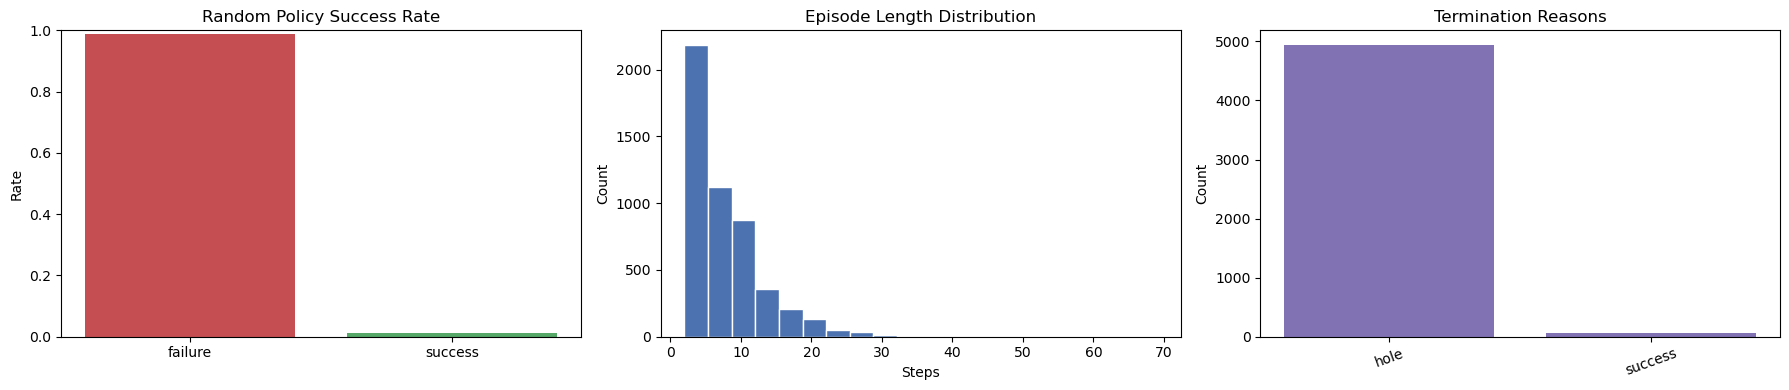

In [13]:
termination_counts = summary["termination_reason"].value_counts().sort_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].bar(["failure", "success"], [1 - success_rate, success_rate], color=["#c44e52", "#55a868"])
axes[0].set_title("Random Policy Success Rate")
axes[0].set_ylabel("Rate")
axes[0].set_ylim(0, 1)

axes[1].hist(episode_lengths, bins=20, color="#4c72b0", edgecolor="white")
axes[1].set_title("Episode Length Distribution")
axes[1].set_xlabel("Steps")
axes[1].set_ylabel("Count")

axes[2].bar(termination_counts.index, termination_counts.values, color="#8172b3")
axes[2].set_title("Termination Reasons")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "random_baseline_overview.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
metrics.to_csv(RESULTS_DIR / "random_baseline_metrics.csv", index=False)
summary.to_csv(RESULTS_DIR / "random_baseline_episode_summary.csv", index=False)

print(f"Success rate: {success_rate:.4f}")
print(f"Average reward: {avg_reward:.4f}")
print(f"Average episode length: {avg_length:.2f}")
print(f"Saved results to: {RESULTS_DIR.resolve()}")

Success rate: 0.0120
Average reward: 0.0120
Average episode length: 7.73
Saved results to: /Users/bizi/Desktop/GitHub/openai-gym-reinforcement-learning-lab/experiments/01-frozenlake-tabular-q-learning/results


## 结果解读

阅读这个 baseline 时，重点看三件事：

- `Success rate` 是否极低
- 回合长度是否大多集中在较短区间，说明随机策略很容易快速失败
- 终止原因里是否主要是掉进冰洞而不是顺利到达终点

如果这些现象都成立，就说明 FrozenLake 对随机策略并不友好。这样在进入 `Q-Learning` 之后，学习曲线和成功率提升就会更有对比意义。